Image loaded successfully
Image shape: (1920, 1080, 3)
Image size: 1080 x 1920


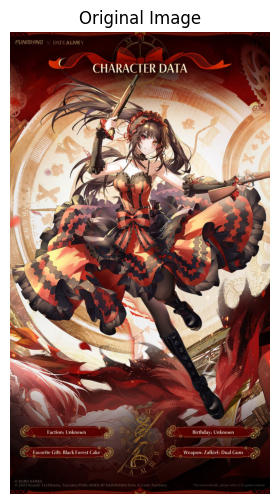

In [ ]:
# LABWORK 6 - MAP
# 6a: Grayscale image binarization
# 6b: Brightness control
# 6c: Blending two images
# 2D block-size experiments

import os
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configuration
IMAGE_PATH = "/content/img.jpg"
BLOCK_SIZE = (16, 16)
THRESHOLD = 128
BRIGHTNESS = 50
ALPHA = 0.5
BLOCK_SIZES = [(4, 4), (8, 8), (16, 16), (32, 32), (64, 64)]

# Load image
if not os.path.isfile(IMAGE_PATH):
    raise FileNotFoundError(
        f"Image not found: {IMAGE_PATH}\n"
        "Please upload img.jpg to /content/"
    )

image = cv2.imread(IMAGE_PATH)

if image is None:
    raise ValueError(f"Could not read image: {IMAGE_PATH}")

print("Image loaded successfully")
print(f"Image shape: {image.shape}")
print(f"Image size: {image.shape[1]} x {image.shape[0]}")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

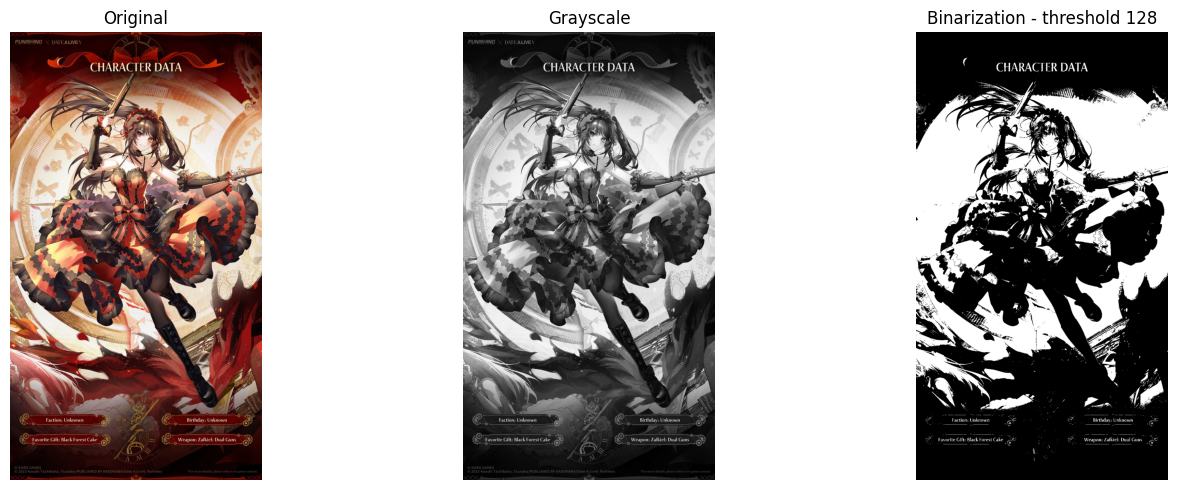

In [ ]:
# Generic 2D BLOCK MAP
def map_2d(image, operation, block_size=(16, 16)):
    height, width = image.shape[:2]
    block_h, block_w = block_size
    result = None
    for y in range(0, height, block_h):
        for x in range(0, width, block_w):

            y_end = min(y + block_h, height)
            x_end = min(x + block_w, width)

            block = image[y:y_end, x:x_end]

            # MAP OPERATION
            processed_block = operation(block)
            if result is None:
                if processed_block.ndim == 2:
                    result = np.empty((height, width), dtype=processed_block.dtype)
                else:
                    result = np.empty((height, width, processed_block.shape[2]), dtype=processed_block.dtype)
            result[y:y_end, x:x_end] = processed_block
    return result

# 6a - GRAYSCALE
def grayscale_operation(block):
    b = block[:, :, 0].astype(np.float32)
    g = block[:, :, 1].astype(np.float32)
    r = block[:, :, 2].astype(np.float32)
    gray = (0.114 * b + 0.587 * g + 0.299 * r)
    return np.clip(gray, 0, 255).astype(np.uint8)

# 6a - BINARIZATION
def binarization_operation(block):
    return np.where(block >= THRESHOLD, 255, 0).astype(np.uint8)

# Run 6a
gray_image = map_2d(image, grayscale_operation, BLOCK_SIZE)
binary_image = map_2d(gray_image, binarization_operation, BLOCK_SIZE)

# Display 6a
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(binary_image, cmap="gray")
plt.title(f"Binarization - threshold {THRESHOLD}")
plt.axis("off")

plt.tight_layout()
plt.show()

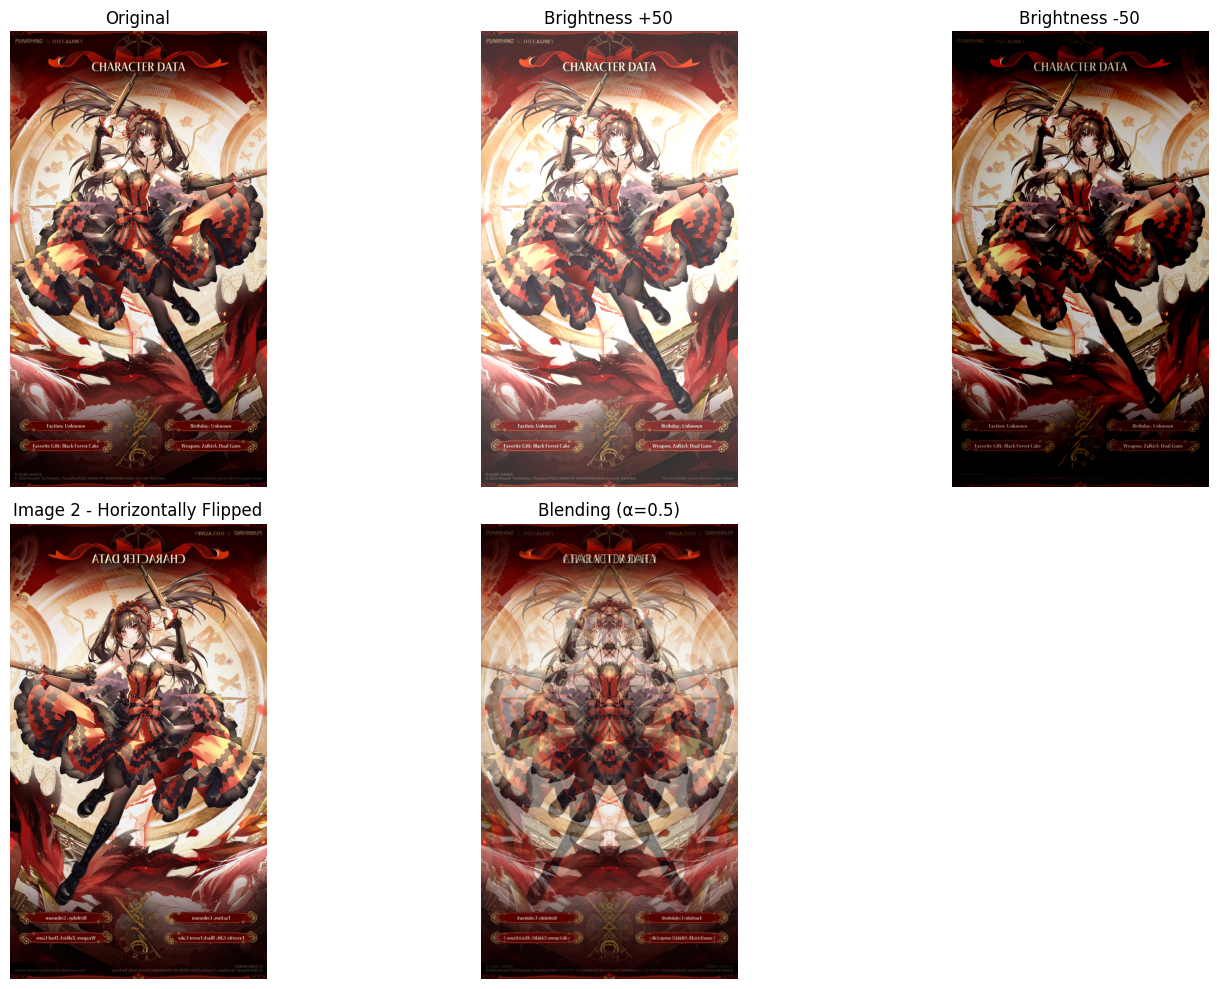

In [ ]:
# 6b - BRIGHTNESS CONTROL
def brightness_operation(block):
    result = (block.astype(np.int16) + BRIGHTNESS)
    return np.clip(result, 0, 255).astype(np.uint8)

# Brightness increase
bright_image = map_2d(image, brightness_operation, BLOCK_SIZE)

# Brightness decrease
def darkening_operation(block):
    result = (block.astype(np.int16) - BRIGHTNESS)
    return np.clip(result, 0, 255).astype(np.uint8)

dark_image = map_2d(image, darkening_operation, BLOCK_SIZE)

# 6c - BLENDING
image2 = cv2.flip(image, 1)

def blend_2d(image1, image2, alpha=0.5, block_size=(16, 16)):
    if image1.shape != image2.shape:
        raise ValueError("Both images must have the same shape.")

    height, width = image1.shape[:2]
    block_h, block_w = block_size
    result = np.empty_like(image1)

    for y in range(0, height, block_h):
        for x in range(0, width, block_w):

            y_end = min(y + block_h, height)
            x_end = min(x + block_w, width)

            block1 = image1[y:y_end, x:x_end].astype(np.float32)
            block2 = image2[y:y_end, x:x_end].astype(np.float32)

            # MAP OPERATION
            blended = (alpha * block1 + (1 - alpha) * block2)

            result[y:y_end, x:x_end] = np.clip(blended, 0, 255).astype(np.uint8)
    return result

blended_image = blend_2d(image, image2, ALPHA, BLOCK_SIZE)

# DISPLAY 6b + 6c
plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(cv2.cvtColor(bright_image, cv2.COLOR_BGR2RGB))
plt.title(f"Brightness +{BRIGHTNESS}")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(cv2.cvtColor(dark_image, cv2.COLOR_BGR2RGB))
plt.title(f"Brightness -{BRIGHTNESS}")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(cv2.cvtColor(image2, cv2.COLOR_BGR2RGB))
plt.title("Image 2 - Horizontally Flipped")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(cv2.cvtColor(blended_image, cv2.COLOR_BGR2RGB))
plt.title(f"Blending (α={ALPHA})")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# 2D BLOCK SIZE EXPERIMENT
benchmark_results = []

for block_size in BLOCK_SIZES:
    print(f"Testing block size: {block_size[0]} x {block_size[1]}")

    # 6a - Binarization
    start = time.perf_counter()
    gray = map_2d(image, grayscale_operation, block_size)
    binary = map_2d(gray, binarization_operation, block_size)
    bin_time = (time.perf_counter() - start)

    # 6b - Brightness
    start = time.perf_counter()
    bright = map_2d(image, brightness_operation,
        block_size
    )

    brightness_time = (
        time.perf_counter() - start
    )

    # 6c - Blending

    start = time.perf_counter()

    blended = blend_2d(
        image,
        image2,
        ALPHA,
        block_size
    )

    blend_time = (
        time.perf_counter() - start
    )

    benchmark_results.append({
        "Block Size":
            f"{block_size[0]} × {block_size[1]}",

        "Binarization (s)":
            bin_time,

        "Brightness (s)":
            brightness_time,

        "Blending (s)":
            blend_time
    })

benchmark_df = pd.DataFrame(benchmark_results)

display(benchmark_df)

Testing block size: 4 x 4
Testing block size: 8 x 8
Testing block size: 16 x 16
Testing block size: 32 x 32
Testing block size: 64 x 64


,Block Size,Binarization (s),Brightness (s),Blending (s)
0,4 × 4,2.782190,1.352838,1.451106
1,8 × 8,0.685726,0.341641,0.366610
2,16 × 16,0.193460,0.101020,0.140893
3,32 × 32,0.065267,0.028354,0.043544
4,64 × 64,0.029156,0.011290,0.021993


In [36]:
# Verify that different block sizes produce the same results

reference_block = (16, 16)

reference_gray = map_2d(
    image,
    grayscale_operation,
    reference_block
)

reference_binary = map_2d(
    reference_gray,
    binarization_operation,
    reference_block
)

reference_bright = map_2d(
    image,
    brightness_operation,
    reference_block
)

reference_blend = blend_2d(
    image,
    image2,
    ALPHA,
    reference_block
)

print("Checking consistency across block sizes...\n")

for block_size in BLOCK_SIZES:

    gray = map_2d(
        image,
        grayscale_operation,
        block_size
    )

    binary = map_2d(
        gray,
        binarization_operation,
        block_size
    )

    bright = map_2d(
        image,
        brightness_operation,
        block_size
    )

    blended = blend_2d(
        image,
        image2,
        ALPHA,
        block_size
    )

    print(
        f"{block_size[0]}x{block_size[1]}:"
    )

    print(
        "  Binarization:",
        np.array_equal(binary, reference_binary)
    )

    print(
        "  Brightness:",
        np.array_equal(bright, reference_bright)
    )

    print(
        "  Blending:",
        np.array_equal(blended, reference_blend)
    )

Checking consistency across block sizes...

4x4:
  Binarization: True
  Brightness: True
  Blending: True
8x8:
  Binarization: True
  Brightness: True
  Blending: True
16x16:
  Binarization: True
  Brightness: True
  Blending: True
32x32:
  Binarization: True
  Brightness: True
  Blending: True
64x64:
  Binarization: True
  Brightness: True
  Blending: True


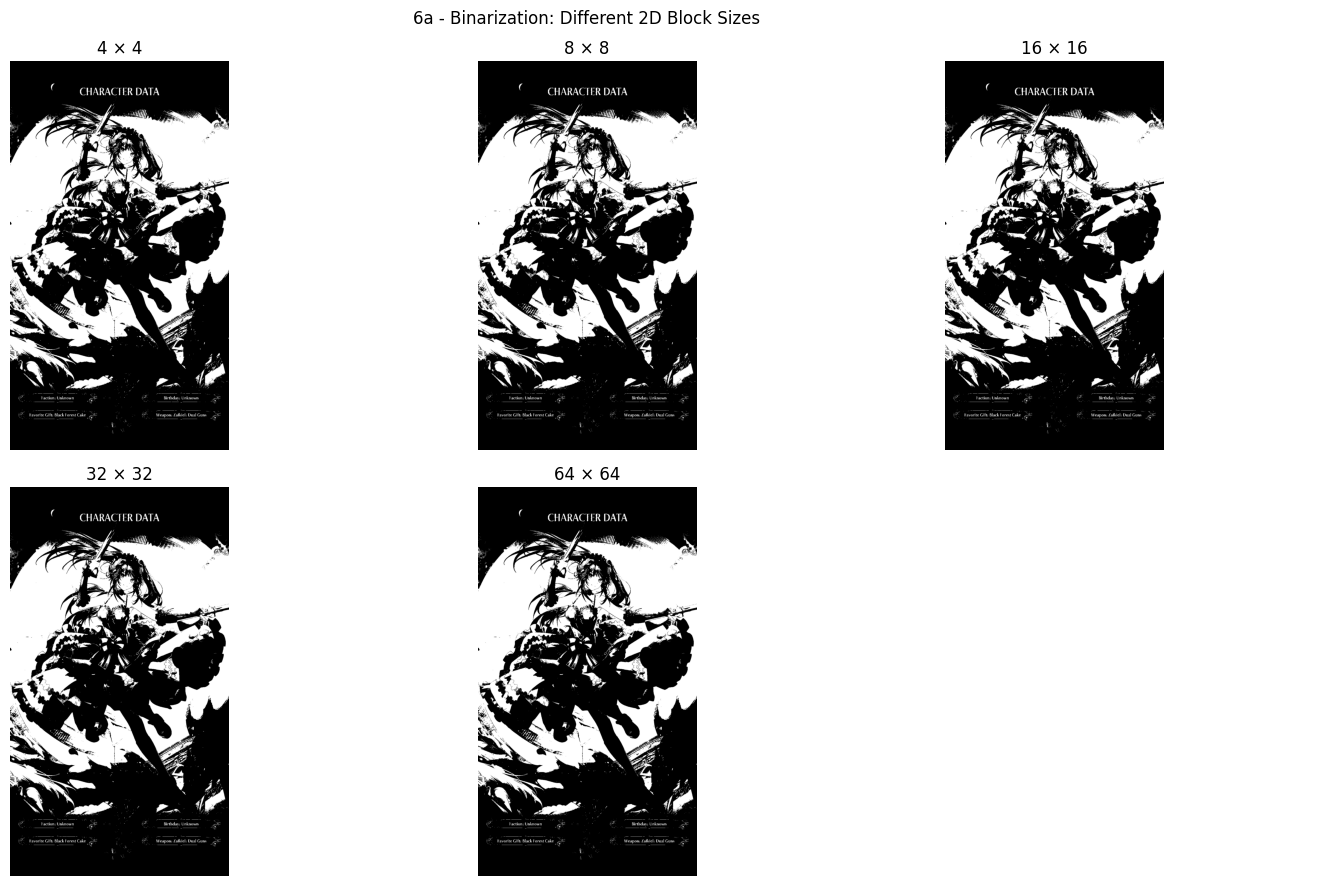

In [37]:
# BLOCK SIZE VISUAL COMPARISON - 6a

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

for ax, block_size in zip(
    axes.flat,
    BLOCK_SIZES
):

    gray = map_2d(
        image,
        grayscale_operation,
        block_size
    )

    binary = map_2d(
        gray,
        binarization_operation,
        block_size
    )

    ax.imshow(
        binary,
        cmap="gray"
    )

    ax.set_title(
        f"{block_size[0]} × {block_size[1]}"
    )

    ax.axis("off")


axes.flat[-1].axis("off")

plt.suptitle(
    "6a - Binarization: Different 2D Block Sizes"
)

plt.tight_layout()
plt.show()

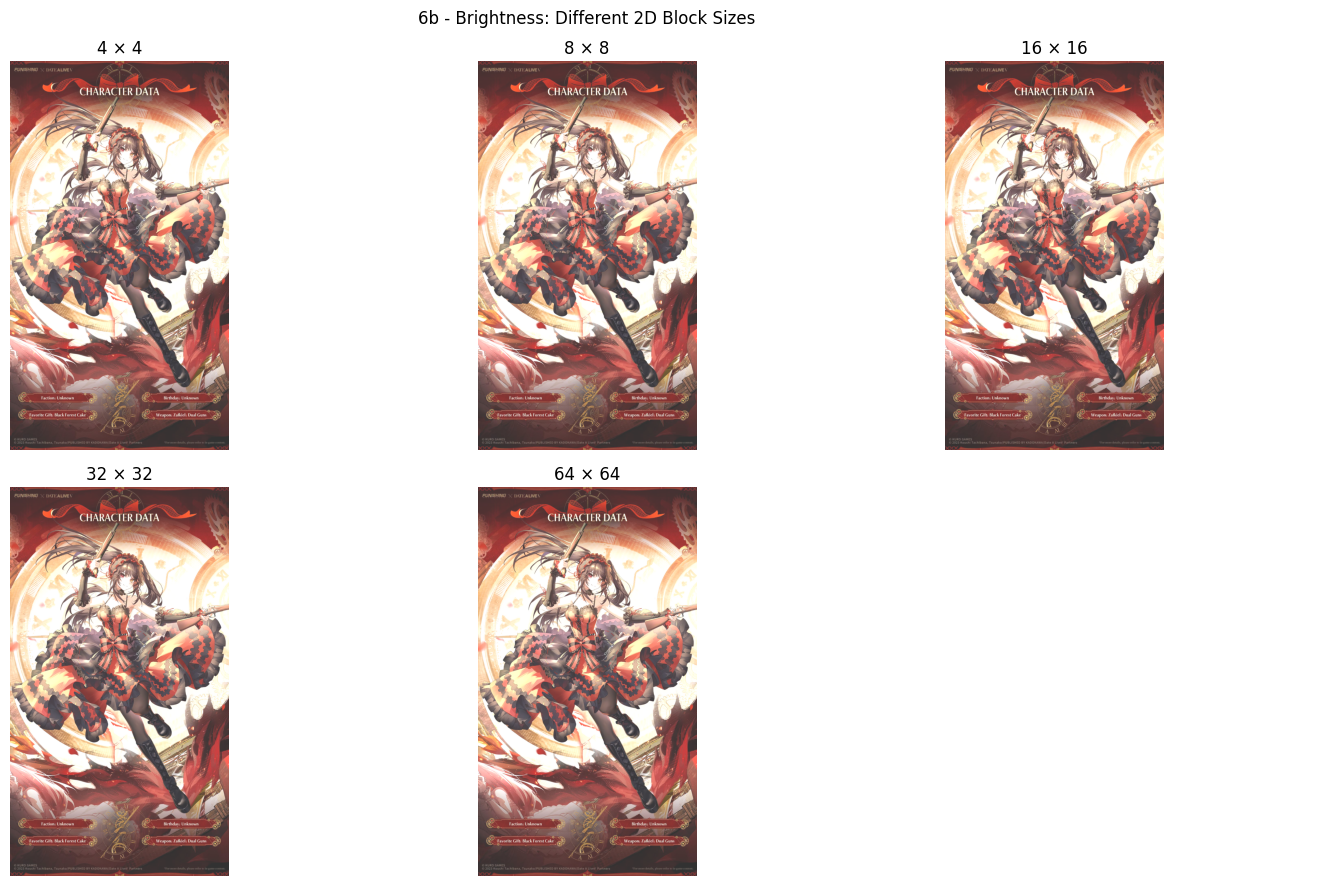

In [38]:
# BLOCK SIZE VISUAL COMPARISON - 6b
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

for ax, block_size in zip(
    axes.flat,
    BLOCK_SIZES
):

    bright = map_2d(
        image,
        brightness_operation,
        block_size
    )

    ax.imshow(
        cv2.cvtColor(
            bright,
            cv2.COLOR_BGR2RGB
        )
    )

    ax.set_title(
        f"{block_size[0]} × {block_size[1]}"
    )

    ax.axis("off")


axes.flat[-1].axis("off")

plt.suptitle(
    "6b - Brightness: Different 2D Block Sizes"
)

plt.tight_layout()
plt.show()

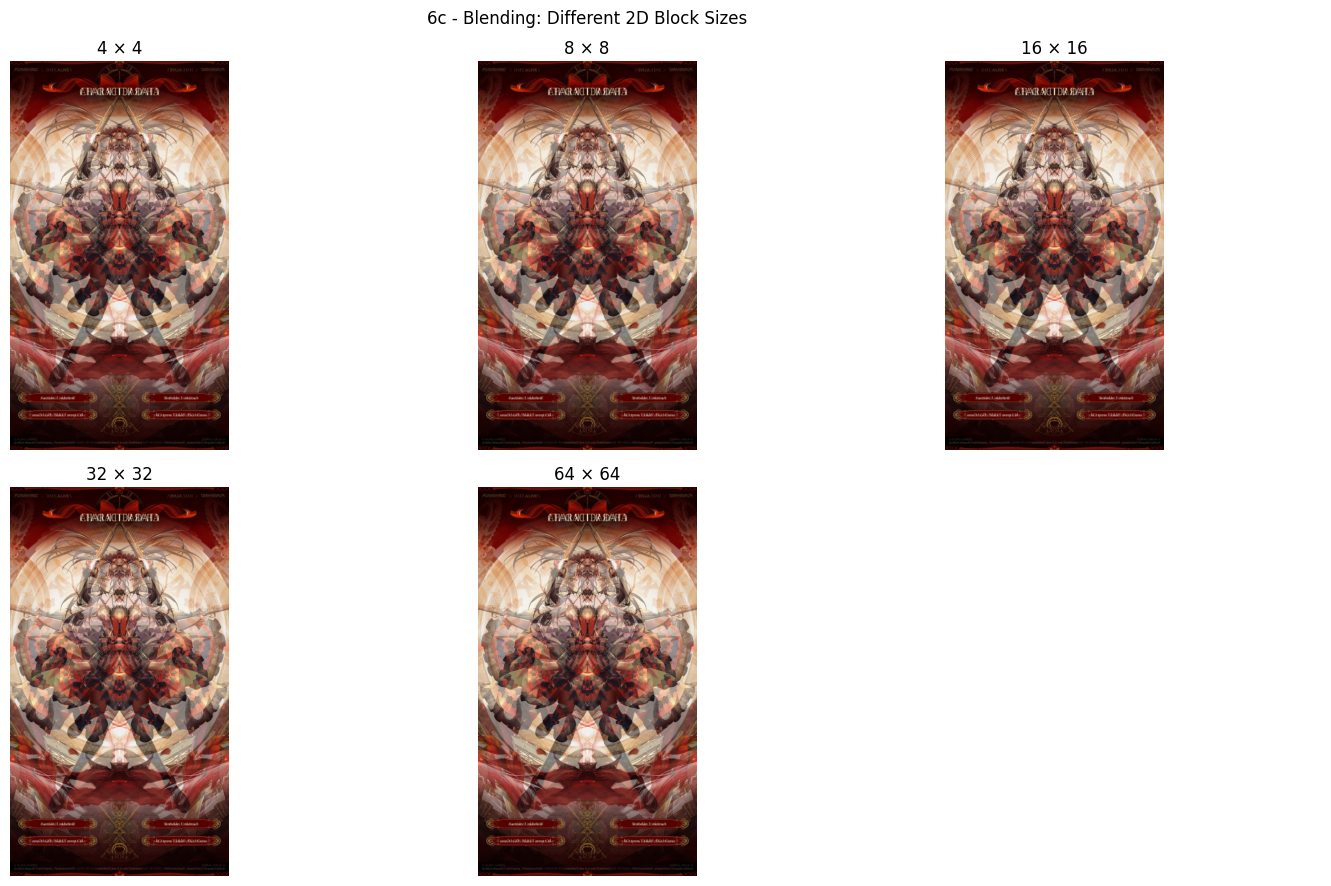

In [39]:
# BLOCK SIZE VISUAL COMPARISON - 6c
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9)
)

for ax, block_size in zip(
    axes.flat,
    BLOCK_SIZES
):

    blended = blend_2d(
        image,
        image2,
        ALPHA,
        block_size
    )

    ax.imshow(
        cv2.cvtColor(
            blended,
            cv2.COLOR_BGR2RGB
        )
    )

    ax.set_title(
        f"{block_size[0]} × {block_size[1]}"
    )

    ax.axis("off")


axes.flat[-1].axis("off")

plt.suptitle(
    "6c - Blending: Different 2D Block Sizes"
)

plt.tight_layout()
plt.show()